<a href="https://colab.research.google.com/github/Lune1525/Digit_Classifier_CNN/blob/main/Digit_Classifier_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras import utils

In [23]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [24]:
len(X_train)

60000

In [25]:
len(X_test)

10000

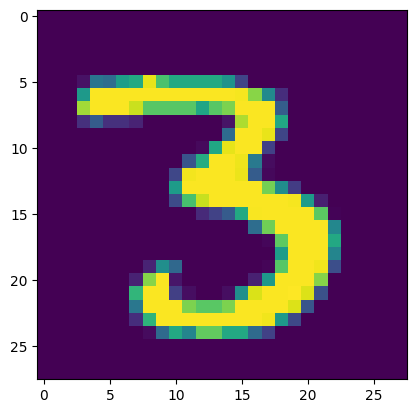

In [27]:
plt.imshow(X_train[12])

X_train.reshape(X_train.shape[0], 28, 28, 1) - passa a altura da imagem, sua largura e o canal, se for colorida é 3 por ser o rgb se for cinza é 1

In [28]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [29]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [30]:
X_train /= 255
X_test /= 255

In [31]:
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [32]:
classifier = Sequential()

classifier.add(Input(shape=(28, 28, 1)))

classifier.add(Conv2D(32, (3, 3), activation='relu'))
classifier.add(BatchNormalization())
classifier.add(MaxPooling2D(pool_size=(2, 2)))

classifier.add(Conv2D(32, (3, 3), activation='relu'))
classifier.add(BatchNormalization())
classifier.add(MaxPooling2D(pool_size=(2, 2)))

classifier.add(Flatten())

classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dropout(0.2))
classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dropout(0.2))

classifier.add(Dense(units=10, activation='softmax'))

classifier.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Starting training...")
classifier.fit(X_train, y_train, batch_size=128, epochs=5, validation_data=(X_test, y_test))

Starting training...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 143ms/step - accuracy: 0.9360 - loss: 0.2084 - val_accuracy: 0.9655 - val_loss: 0.1182
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.9812 - loss: 0.0643 - val_accuracy: 0.9874 - val_loss: 0.0381
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 130ms/step - accuracy: 0.9861 - loss: 0.0473 - val_accuracy: 0.9840 - val_loss: 0.0476
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.9886 - loss: 0.0379 - val_accuracy: 0.9852 - val_loss: 0.0518
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.9909 - loss: 0.0311 - val_accuracy: 0.9873 - val_loss: 0.0383


In [33]:
result = classifier.evaluate(X_test, y_test)
print(f"Test Loss: {result[0]:.4f}")
print(f"Test Accuracy: {result[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9873 - loss: 0.0383
Test Loss: 0.0383
Test Accuracy: 0.9873
